# Assignment 2 - YouTube Data Collection and Cleaning

## 1. Aim

Collect YouTube video metadata and comments for videos discussing AI coding assistants such as GitHub Copilot, Cursor, Claude Code, Codex, AI coding agents, and related developer workflow topics.

The collected data should support:

- NLP/text analysis of comment themes, sentiment, and concerns.
- Network analysis using video-commenter, commenter-video, and co-commenting relationships.

In [1]:
import json
import re
import string
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd

from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
project_root_str = str(PROJECT_ROOT.resolve())
if project_root_str not in sys.path:
    sys.path.append(project_root_str)

from src.utils.youtube_client import youtubeClient

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gayathwethmin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Quota Tracking

YouTube Data API v3 has a default daily quota of 10,000 units.
Each `commentThreads.list` or `comments.list` page request costs 1 unit.
We track usage throughout collection and stop at 9,500 to leave a safe buffer.

In [2]:
QUOTA_LIMIT = 9500
quota_used = 0

def charge_quota(units=1):
    global quota_used
    quota_used += units
    if quota_used >= QUOTA_LIMIT:
        raise Exception(f"Quota limit reached ({quota_used} units). Stopping collection.")

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = PROJECT_ROOT / "data/raw/youtube"
PROCESSED_DIR = PROJECT_ROOT / "data/processed/youtube"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MAX_VIDEOS = 20
MAX_COMMENTS_PER_VIDEO = 200

## Data Collection Function

Collection follows this structure:
1. Search YouTube for videos matching a query
2. Pull video-level metadata and statistics
3. Pull top-level comments for each video (up to `maxCommentsPerVideo`)
4. Pull replies for threaded comments (reply_count > 0) to build directed network edges
5. Save one nested JSON file per search query

Replies are collected because they provide directed edges (replier → commenter)
for the network analysis component. Only comments with 2+ replies are fetched
to preserve quota budget.

In [4]:
def fetchYoutubeData(
    searchQuery,
    maxVideos=25,
    maxCommentsPerVideo=200,
    outputFile="youtubeDataDump.json",
):
    global quota_used
    client = youtubeClient()

    # Search for videos
    charge_quota(100)  # search.list costs 100 units
    searchResponse = client.search().list(
        q=searchQuery,
        part="snippet",
        type="video",
        order="relevance",
        maxResults=min(maxVideos, 50),
    ).execute()

    videoIds = []
    videoSnippets = {}
    for item in searchResponse.get("items", []):
        videoId = item["id"]["videoId"]
        videoIds.append(videoId)
        videoSnippets[videoId] = item["snippet"]

    # Get video statistics
    videoStats = {}
    if videoIds:
        charge_quota(1)
        statsResponse = client.videos().list(
            id=",".join(videoIds),
            part="statistics",
        ).execute()
        for item in statsResponse.get("items", []):
            videoStats[item["id"]] = item["statistics"]

    videos = []
    all_reply_edges = []

    for searchRank, videoId in enumerate(videoIds, start=1):
        snippet = videoSnippets[videoId]
        stats = videoStats.get(videoId, {})

        video = {
            "sourceQuery": searchQuery,
            "searchRank": searchRank,
            "title": snippet["title"],
            "videoId": videoId,
            "channelTitle": snippet["channelTitle"],
            "publishedAt": snippet["publishedAt"],
            "viewCount": int(stats.get("viewCount", 0)),
            "likeCount": int(stats.get("likeCount", 0)),
            "commentCount": int(stats.get("commentCount", 0)),
            "comments": [],
        }

        try:
            comments_fetched = 0
            next_page_token = None
            top_level_comments = []

            # Fetch top-level comments
            while True:
                remaining = maxCommentsPerVideo - comments_fetched
                if remaining <= 0:
                    break

                charge_quota(1)
                commentResponse = client.commentThreads().list(
                    videoId=videoId,
                    part="snippet",
                    maxResults=min(100, remaining),
                    pageToken=next_page_token,
                    textFormat="plainText",
                ).execute()

                for thread in commentResponse.get("items", []):
                    top = thread["snippet"]["topLevelComment"]["snippet"]
                    reply_count = thread["snippet"].get("totalReplyCount", 0)

                    comment = {
                        "commentId": thread["id"],
                        "author": top["authorDisplayName"],
                        "authorChannelId": top.get("authorChannelId", {}).get("value", ""),
                        "text": top["textDisplay"],
                        "publishedAt": top["publishedAt"],
                        "likeCount": top.get("likeCount", 0),
                        "replyCount": reply_count,
                        "type": "top_level",
                        "parentAuthor": None,
                    }
                    video["comments"].append(comment)
                    top_level_comments.append(comment)
                    comments_fetched += 1

                    if comments_fetched >= maxCommentsPerVideo:
                        break

                next_page_token = commentResponse.get("nextPageToken")
                if not next_page_token or comments_fetched >= maxCommentsPerVideo:
                    break

            # Fetch replies for threaded comments 
            threaded = [c for c in top_level_comments if c["replyCount"] > 0]
            for comment in threaded:
                try:
                    charge_quota(1)
                    replyResponse = client.comments().list(
                        part="snippet",
                        parentId=comment["commentId"],
                        maxResults=100,
                        textFormat="plainText",
                    ).execute()

                    for item in replyResponse.get("items", []):
                        s = item["snippet"]
                        reply = {
                            "commentId": item["id"],
                            "author": s.get("authorDisplayName", ""),
                            "authorChannelId": s.get("authorChannelId", {}).get("value", ""),
                            "text": s.get("textDisplay", ""),
                            "publishedAt": s.get("publishedAt", ""),
                            "likeCount": s.get("likeCount", 0),
                            "replyCount": 0,
                            "type": "reply",
                            "parentAuthor": comment["author"],
                        }
                        video["comments"].append(reply)

                        # Directed edge: replier → original commenter
                        all_reply_edges.append({
                            "source": reply["author"],
                            "target": comment["author"],
                            "videoId": videoId,
                            "commentId": reply["commentId"],
                            "publishedAt": reply["publishedAt"],
                        })

                except Exception as e:
                    print(f"  Reply fetch error for comment {comment['commentId']}: {e}")

        except Exception as e:
            print(f"Comments disabled or error for video {videoId}: {e}")

        videos.append(video)
        print(f"  [{searchRank}] {video['title'][:60]} — {len(video['comments'])} comments | quota used: {quota_used}")

    data = {
        "searchQuery": searchQuery,
        "videos": videos,
        "replyEdges": all_reply_edges
    }

    with open(outputFile, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(videos)} videos, {sum(len(v['comments']) for v in videos)} comments, {len(all_reply_edges)} reply edges → {outputFile}")
    print(f"Quota used so far: {quota_used}/{QUOTA_LIMIT}")

## 3. Search Terms

These are starting terms only. After the first run, inspect the video titles and remove terms that bring in irrelevant videos.

In [5]:
SEARCH_QUERIES = [
    "GitHub Copilot review developers",
    "GitHub Copilot coding assistant",
    "Cursor AI code editor review",
    "Claude Code coding assistant",
    "OpenAI Codex coding agent",
    "AI coding agents software development",
    "AI code assistant programmer productivity",
    "vibe coding developers",
    "AI replacing programmers software developers",
    "AI coding assistant security privacy",
]

for index, searchQuery in enumerate(SEARCH_QUERIES, start=1):
    output_file = RAW_DIR / f"youtube_ai_coding_{index}.json"
    fetchYoutubeData(
        searchQuery,
        maxVideos=MAX_VIDEOS,
        maxCommentsPerVideo=MAX_COMMENTS_PER_VIDEO,
        outputFile=str(output_file),
    )

  [1] Get to know GitHub Copilot in VS Code and be productive IMME — 164 comments | quota used: 123
  [2] How to automate code reviews and testing with GitHub Copilot — 49 comments | quota used: 124
  [3] 10 GitHub Copilot Tricks Most Developers Don&#39;t Know (202 — 9 comments | quota used: 128
  [4] Github Copilot Can Now Review Your Code 🤯 #githubcopilot #we — 11 comments | quota used: 130
  [5] GitHub Copilot | Honest Review (MUST WATCH) — 0 comments | quota used: 131
  [6] When to use GitHub Copilot coding agent versus agent mode — 19 comments | quota used: 135
  [7] How the GitHub Copilot coding agent works | GitHub Checkout — 37 comments | quota used: 142
  [8] Using GitHub Copilot for code reviews: from VS Code to githu — 95 comments | quota used: 150
  [9] How I Code with GitHub Copilot in Visual Studio 2022 to Boos — 85 comments | quota used: 173
  [10] Yes, GitHub Copilot knows about your whole codebase — 13 comments | quota used: 174
  [11] GitHub Copilot code review | New 

## 4. Convert Nested JSON into a Comment Table

The raw JSON is nested by video. This converts it into one row per comment, with video metadata attached to each comment.

In [9]:
videos_parsed = []
seen_video_ids = set()

for json_file in sorted(RAW_DIR.glob("youtube_ai_coding_*.json")):
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for video in data.get("videos", []):
        video_id = video["videoId"]

        if video.get("comments") and video_id not in seen_video_ids:
            videos_parsed.append(video)
            seen_video_ids.add(video_id)

video_comments = []
for video in videos_parsed:
    for comment in video["comments"]:
        video_comments.append({
            "sourceQuery": video.get("sourceQuery"),
            "searchRank": video.get("searchRank"),
            "videoId": video["videoId"],
            "title": video["title"],
            "channelTitle": video["channelTitle"],
            "publishedAt": video["publishedAt"],
            "viewCount": video["viewCount"],
            "likeCount": video["likeCount"],
            "videoCommentCount": video.get("commentCount", 0),
            "commentAuthor": comment["author"],
            "commentText": comment["text"],
            "commentType": comment.get("type", "top_level"),
            "parentAuthor": comment.get("parentAuthor", None),
            "commentPublishedAt": comment["publishedAt"],
            "commentLikeCount": comment["likeCount"],
        })

comments_df = pd.DataFrame(video_comments)
comments_df = comments_df.drop_duplicates(subset=["videoId", "commentAuthor", "commentText"]).reset_index(drop=True)
print(f"After dedup: {len(comments_df)} comments")
comments_df.to_csv(PROCESSED_DIR / "YTCommentsRawFlattened.csv", index=False)

print(f"Unique videos with comments: {len(videos_parsed)}")
print(f"Total comments collected: {len(video_comments)}")
comments_df.head()

After dedup: 23895 comments
Unique videos with comments: 165
Total comments collected: 24077


,sourceQuery,searchRank,videoId,title,channelTitle,publishedAt,viewCount,likeCount,videoCommentCount,commentAuthor,commentText,commentType,parentAuthor,commentPublishedAt,commentLikeCount
0,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15T14:22:36Z,739081,9142,164,@alsacs3635,Good overview. Thanks for sharing.,top_level,None,2026-05-15T02:18:09Z,0
1,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15T14:22:36Z,739081,9142,164,@thudtheace,Total trash!! Did you unleash copilot on GIT t...,top_level,None,2026-04-29T14:34:19Z,0
2,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15T14:22:36Z,739081,9142,164,@moxopixel,Now it sucks,top_level,None,2026-04-24T16:04:13Z,0
3,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15T14:22:36Z,739081,9142,164,@earthskysea1111,CNTL + ENTER sends stuff to the terminal for m...,top_level,None,2026-04-08T21:43:49Z,0
4,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15T14:22:36Z,739081,9142,164,@TamilSelvanB-u4q,Wonderful Explanation,top_level,None,2026-02-19T09:07:52Z,0


In [15]:
print(comments_df[["videoId", "commentAuthor", "commentText", "commentPublishedAt"]].head(10))

       videoId      commentAuthor  \
0  jXp5D5ZnxGM        @alsacs3635   
1  jXp5D5ZnxGM        @thudtheace   
2  jXp5D5ZnxGM         @moxopixel   
3  jXp5D5ZnxGM   @earthskysea1111   
4  jXp5D5ZnxGM  @TamilSelvanB-u4q   
5  jXp5D5ZnxGM    @FerjanaMousomi   
6  jXp5D5ZnxGM       @cornsalad14   
7  jXp5D5ZnxGM   @firstlast-ty4di   
8  jXp5D5ZnxGM       @s_madhan623   
9  jXp5D5ZnxGM    @akashbarot9299   

                                         commentText        commentPublishedAt  
0                 Good overview. Thanks for sharing. 2026-05-15 02:18:09+00:00  
1  Total trash!! Did you unleash copilot on GIT t... 2026-04-29 14:34:19+00:00  
2                                       Now it sucks 2026-04-24 16:04:13+00:00  
3  CNTL + ENTER sends stuff to the terminal for m... 2026-04-08 21:43:49+00:00  
4                              Wonderful Explanation 2026-02-19 09:07:52+00:00  
5                               It is a useful video 2026-01-22 17:06:02+00:00  
6  In the chat, shouldn't

## 5. Basic Data Checks

In [10]:
comments_df.shape

comments_df.info()

video_summary = comments_df.groupby([
    "videoId",
    "title",
    "channelTitle",
    "publishedAt",
]).agg(
    collectedCommentCount=("commentText", "count"),
    viewCount=("viewCount", "first"),
    likeCount=("likeCount", "first"),
    videoCommentCount=("videoCommentCount", "first"),
).reset_index()

video_summary.sort_values("collectedCommentCount", ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23895 entries, 0 to 23894
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   sourceQuery         23895 non-null  object
 1   searchRank          23895 non-null  int64 
 2   videoId             23895 non-null  object
 3   title               23895 non-null  object
 4   channelTitle        23895 non-null  object
 5   publishedAt         23895 non-null  object
 6   viewCount           23895 non-null  int64 
 7   likeCount           23895 non-null  int64 
 8   videoCommentCount   23895 non-null  int64 
 9   commentAuthor       23895 non-null  object
 10  commentText         23895 non-null  object
 11  commentType         23895 non-null  object
 12  parentAuthor        5710 non-null   object
 13  commentPublishedAt  23895 non-null  object
 14  commentLikeCount    23895 non-null  int64 
dtypes: int64(5), object(10)
memory usage: 2.7+ MB


,videoId,title,channelTitle,publishedAt,collectedCommentCount,viewCount,likeCount,videoCommentCount
91,ZkGzEMDeJos,OpenAI Codex Explained for Normal People (“Cla...,Paul J Lipsky,2026-05-05T13:01:07Z,358,123317,3511,373
45,FwOTs4UxQS4,"AI Agents, Clearly Explained",Jeff Su,2025-04-08T13:00:28Z,342,4339418,104879,2790
67,N_wq9OV4T4c,Will AI replace programmers? - NVIDIA CEO expl...,Lex Clips,2026-03-24T06:47:18Z,335,125240,2730,350
11,4V5G3wtrmhg,I&#39;ve Changed My Opinion On DEVELOPERS Vibe...,Traversy Media,2026-05-18T15:00:06Z,327,46948,2228,328
95,aefn-HldCi4,Can AI replace programmers in 5 years?,Bhuva's Impact Global,2023-12-22T03:30:00Z,327,317707,2249,332
4,0e-Brv-gS9Q,A first look at the Codex app,OpenAI,2026-02-02T18:03:33Z,317,104751,3065,372
136,rp5EwOogWEw,The Ultimate Local AI Coding Guide For 2026,Zen van Riel,2025-10-21T13:01:46Z,317,267264,7074,521
30,Bc98jtvwkQ8,This is Why AI Could Replace Programmers,Nick Chapsas,2026-04-13T10:45:00Z,298,49294,1881,321
162,yn1QKuCQXO8,Why Real Programmers LAUGH About No Code Tools...,Philipp Lackner,2023-10-28T12:00:58Z,286,472336,10041,708
105,fQeybL6w-Wo,The next two years of software dev...,Awesome,2026-02-25T10:00:59Z,286,175548,6024,636


Video date range: 2023-10-28 12:00:58+00:00 to 2026-05-20 11:30:08+00:00
Comment date range: 2023-11-07 12:46:34+00:00 to 2026-05-22 23:08:39+00:00


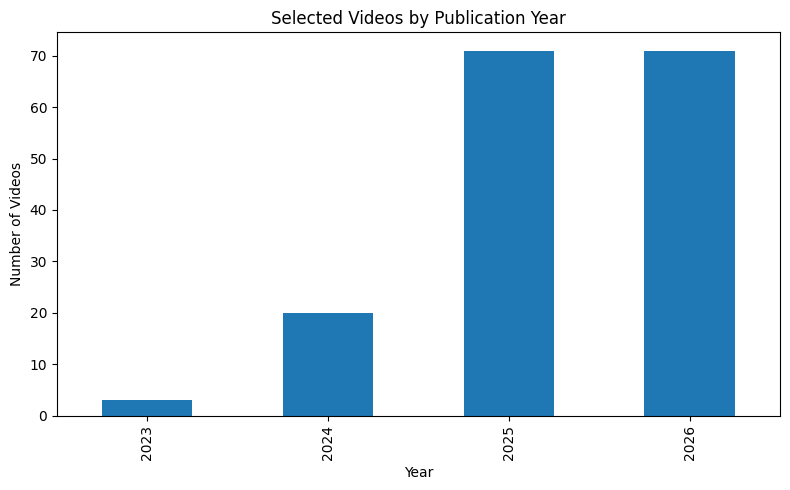

In [11]:
comments_df["publishedAt"] = pd.to_datetime(comments_df["publishedAt"], errors="coerce")
comments_df["commentPublishedAt"] = pd.to_datetime(comments_df["commentPublishedAt"], errors="coerce")

print("Video date range:", comments_df["publishedAt"].min(), "to", comments_df["publishedAt"].max())
print("Comment date range:", comments_df["commentPublishedAt"].min(), "to", comments_df["commentPublishedAt"].max())

video_summary["publishedAt"] = pd.to_datetime(video_summary["publishedAt"], errors="coerce")
video_summary["year"] = video_summary["publishedAt"].dt.year

video_summary["year"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))
plt.title("Selected Videos by Publication Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

## 6. Title Relevance Check

This is a rough first-pass check. The final video list should still be manually reviewed before analysis.

Video titles in the dataset:
Get to know GitHub Copilot in VS Code and be productive IMMEDIATELY
How to automate code reviews and testing with GitHub Copilot
10 GitHub Copilot Tricks Most Developers Don&#39;t Know (2026)
Github Copilot Can Now Review Your Code 🤯 #githubcopilot #webdeveloper #webdev #programmer #reactjs
When to use GitHub Copilot coding agent versus agent mode
How the GitHub Copilot coding agent works | GitHub Checkout
Using GitHub Copilot for code reviews: from VS Code to github.com
How I Code with GitHub Copilot in Visual Studio 2022 to Boost Productivity Everyday
Yes, GitHub Copilot knows about your whole codebase
GitHub Copilot code review | New feature announcement
What&#39;s new with GitHub Copilot code review (CodeQL, agents &amp; more)
How to Use GitHub Copilot Agent Mode - Visual Studio 2026 | Tips &amp; Tutorial
GitHub Copilot Just Died
How to use agents, skills, and instructions in Copilot CLI | Tutorial for beginners
How to close pull requests faster with Co

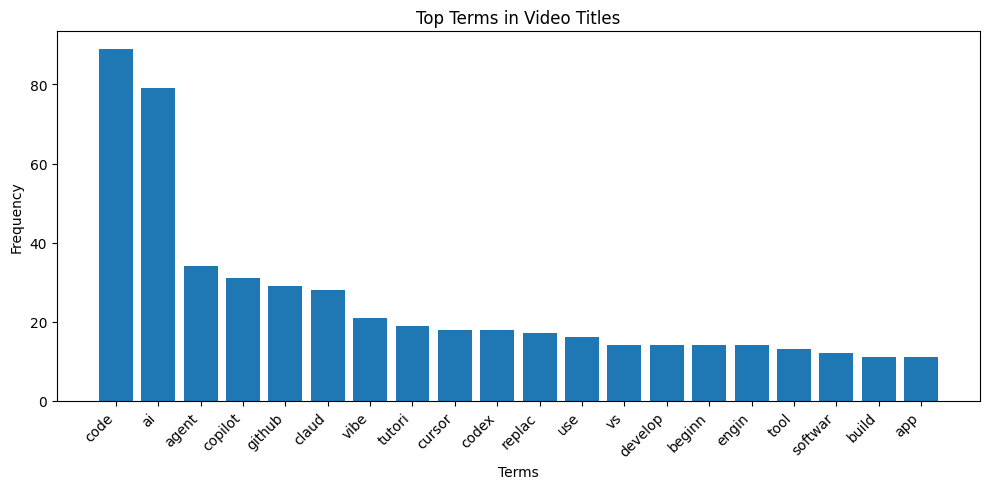

In [12]:
print("Video titles in the dataset:")
for videoTitle in comments_df["title"].drop_duplicates():
    print(videoTitle)


def processText(text, tokenizer, stemmer, stopwords_list):
    text = str(text).lower()
    lTokens = tokenizer.tokenize(text)
    lTokens = [token.strip() for token in lTokens]
    lStemmedTokens = set([stemmer.stem(tok) for tok in lTokens])

    return [tok for tok in lStemmedTokens if tok not in stopwords_list and not tok.isdigit()]


termFreqCounter = Counter()

commentTokeniser = TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = stopwords.words("english") + lPunct + ["via"]
commentStemmer = nltk.stem.PorterStemmer()

for videoTitle in comments_df["title"].drop_duplicates():
    lTokens = processText(
        text=videoTitle,
        tokenizer=commentTokeniser,
        stemmer=commentStemmer,
        stopwords_list=lStopwords,
    )
    termFreqCounter.update(lTokens)

top_terms = termFreqCounter.most_common(20)
print("\nMost common terms in video titles:", top_terms)

if top_terms:
    terms, frequencies = zip(*top_terms)
    plt.figure(figsize=(10, 5))
    plt.bar(terms, frequencies)
    plt.title("Top Terms in Video Titles")
    plt.xlabel("Terms")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [13]:
include_keywords = [
    "ai",
    "copilot",
    "github copilot",
    "cursor",
    "claude code",
    "codex",
    "coding assistant",
    "code assistant",
    "coding agent",
    "developer",
    "developers",
    "programmer",
    "programmers",
    "software engineer",
    "software development",
    "vibe coding",
    "productivity",
    "security",
    "privacy",
]


def relevance_score(title):
    title_lower = str(title).lower()
    return sum(keyword in title_lower for keyword in include_keywords)


video_summary["relevanceScore"] = video_summary["title"].apply(relevance_score)

top_videos = (
    video_summary.sort_values(["relevanceScore", "collectedCommentCount"], ascending=False)
    [["videoId", "title", "channelTitle", "publishedAt", "collectedCommentCount", "relevanceScore"]]
)

print(top_videos.to_string(index=False))

    videoId                                                                                                  title                      channelTitle               publishedAt  collectedCommentCount  relevanceScore
Wl5NJVieiBM                                         Github Copilot vs Cursor: which AI coding assistant is better?                Steve (Builder.io) 2024-12-20 15:25:45+00:00                    160               5
-PlkQno5q50          GitHub Copilot is DONE #programmer #coder #softwareengineer #dev #webdev #ai #github #copilot                               PGT 2024-11-26 20:51:16+00:00                    207               4
wlpBCazAY9Q            AI-Assisted Coding Tutorial – OpenClaw, GitHub Copilot, Claude Code, CodeRabbit, Gemini CLI                  freeCodeCamp.org 2026-03-31 10:01:00+00:00                    130               4
CusQM9FEq3E                                   Claude Code vs GitHub Copilot Agent: Which AI Dev Tool Wins in 2026?                    Savage Rev

## 7. Manual Video Selection

After reviewing the title list above, paste the video IDs to keep into `selected_video_ids`. If this list is empty, the notebook keeps all videos that passed the earlier collection step.

In [16]:
selected_video_ids = [
    # Example:
    # "abc123xyz",
]

if selected_video_ids:
    filtered_comments_df = comments_df[comments_df["videoId"].isin(selected_video_ids)].copy()
else:
    filtered_comments_df = comments_df.copy()

print("Selected videos:", filtered_comments_df["videoId"].nunique())
print("Selected comments:", len(filtered_comments_df))

Selected videos: 165
Selected comments: 23895


## 8. Data Cleaning

This stage removes duplicate comments, removes empty comments, converts dates, and adds simple text-cleaning fields for later NLP.

In [17]:
before_rows = len(filtered_comments_df)

filtered_comments_df = filtered_comments_df.drop_duplicates(
    subset=["videoId", "commentAuthor", "commentText"]
).copy()

after_rows = len(filtered_comments_df)

print(f"Removed duplicate comments: {before_rows - after_rows}")
print(f"Remaining comments: {after_rows}")

Removed duplicate comments: 0
Remaining comments: 23895


In [ ]:
filtered_comments_df = filtered_comments_df[filtered_comments_df["commentText"].notna()].copy()
filtered_comments_df = filtered_comments_df[
    filtered_comments_df["commentText"].astype(str).str.strip() != ""
].copy()

filtered_comments_df["publishedAt"] = pd.to_datetime(
    filtered_comments_df["publishedAt"],
    errors="coerce",
)

filtered_comments_df["commentPublishedAt"] = pd.to_datetime(
    filtered_comments_df["commentPublishedAt"],
    errors="coerce",
)

filtered_comments_df = filtered_comments_df[
    filtered_comments_df["commentPublishedAt"].notna()
].copy()

print(f"Dataset shape after empty-comment/date cleaning: {filtered_comments_df.shape}")
print("Comment date range:", filtered_comments_df["commentPublishedAt"].min(), "to", filtered_comments_df["commentPublishedAt"].max())

In [18]:
def clean_comment_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


filtered_comments_df["commentTextClean"] = filtered_comments_df["commentText"].apply(clean_comment_text)
filtered_comments_df["commentTextLower"] = filtered_comments_df["commentTextClean"].str.lower()
filtered_comments_df["commentLength"] = filtered_comments_df["commentTextClean"].str.len()

filtered_comments_df = filtered_comments_df[filtered_comments_df["commentLength"] > 0].copy()

filtered_comments_df.head()

,sourceQuery,searchRank,videoId,title,channelTitle,publishedAt,viewCount,likeCount,videoCommentCount,commentAuthor,commentText,commentType,parentAuthor,commentPublishedAt,commentLikeCount,commentTextClean,commentTextLower,commentLength
0,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@alsacs3635,Good overview. Thanks for sharing.,top_level,None,2026-05-15 02:18:09+00:00,0,Good overview. Thanks for sharing.,good overview. thanks for sharing.,34
1,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@thudtheace,Total trash!! Did you unleash copilot on GIT t...,top_level,None,2026-04-29 14:34:19+00:00,0,Total trash!! Did you unleash copilot on GIT t...,total trash!! did you unleash copilot on git t...,184
2,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@moxopixel,Now it sucks,top_level,None,2026-04-24 16:04:13+00:00,0,Now it sucks,now it sucks,12
3,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@earthskysea1111,CNTL + ENTER sends stuff to the terminal for m...,top_level,None,2026-04-08 21:43:49+00:00,0,CNTL + ENTER sends stuff to the terminal for m...,cntl + enter sends stuff to the terminal for m...,72
4,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@TamilSelvanB-u4q,Wonderful Explanation,top_level,None,2026-02-19 09:07:52+00:00,0,Wonderful Explanation,wonderful explanation,21


In [19]:
filtered_comments_df.to_csv(PROCESSED_DIR / "YTCommentsCleaned.csv", index=False)

final_video_summary = filtered_comments_df.groupby([
    "videoId",
    "title",
    "channelTitle",
]).agg(
    collectedCommentCount=("commentTextClean", "count"),
    uniqueCommenters=("commentAuthor", "nunique"),
    averageCommentLength=("commentLength", "mean"),
    viewCount=("viewCount", "first"),
    likeCount=("likeCount", "first"),
).reset_index()

final_video_summary.to_csv(PROCESSED_DIR / "YTVideoSummary.csv", index=False)

print("Saved:")
print(PROCESSED_DIR / "YTCommentsCleaned.csv")
print(PROCESSED_DIR / "YTVideoSummary.csv")

print("\nFinal dataset shape:", filtered_comments_df.shape)
print("Final unique videos:", filtered_comments_df["videoId"].nunique())
print("Final unique commenters:", filtered_comments_df["commentAuthor"].nunique())
print("Final total comments:", len(filtered_comments_df))

Saved:
/Users/gayathwethmin/Downloads/social_media_2/data/processed/youtube/YTCommentsCleaned.csv
/Users/gayathwethmin/Downloads/social_media_2/data/processed/youtube/YTVideoSummary.csv

Final dataset shape: (23871, 18)
Final unique videos: 165
Final unique commenters: 19589
Final total comments: 23871


In [23]:
print("=== Collection Summary ===")
print(f"Total comments:       {len(filtered_comments_df)}")
print(f"Unique videos:        {filtered_comments_df['videoId'].nunique()}")
print(f"Unique commenters:    {filtered_comments_df['commentAuthor'].nunique()}")
print(f"Top-level comments:   {len(filtered_comments_df[filtered_comments_df['commentType'] == 'top_level'])}")
print(f"Replies:              {len(filtered_comments_df[filtered_comments_df['commentType'] == 'reply'])}")
print(f"Date range:           {filtered_comments_df['commentPublishedAt'].min()} → {filtered_comments_df['commentPublishedAt'].max()}")
print(f"Avg comment length:   {filtered_comments_df['commentLength'].mean():.0f} chars")

=== Collection Summary ===
Total comments:       23871
Unique videos:        165
Unique commenters:    19589
Top-level comments:   18166
Replies:              5705
Date range:           2023-11-07 12:46:34+00:00 → 2026-05-22 23:08:39+00:00
Avg comment length:   138 chars


## 9. Network Edge Tables

These edge tables are used as inputs for the network analysis stage.

- `video_commenter_edges`: connects each video to each commenter.
- `commenter_video_edges`: same relationship in the opposite column order, useful for bipartite graphs.

In [20]:
video_commenter_edges = (
    filtered_comments_df
    .groupby(["videoId", "commentAuthor"])
    .agg(weight=("commentTextClean", "count"))
    .reset_index()
)

commenter_video_edges = video_commenter_edges.rename(
    columns={"commentAuthor": "source", "videoId": "target"}
)[["source", "target", "weight"]]

video_commenter_edges.to_csv(PROCESSED_DIR / "YTVideoCommenterEdges.csv", index=False)
commenter_video_edges.to_csv(PROCESSED_DIR / "YTCommenterVideoEdges.csv", index=False)

video_commenter_edges.head()

,videoId,commentAuthor,weight
0,-PlkQno5q50,@0EEVV0,1
1,-PlkQno5q50,@0w784g,1
2,-PlkQno5q50,@123Handbuch,1
3,-PlkQno5q50,@Alx-je7oj,1
4,-PlkQno5q50,@BingleBangleBungle,1


### Reply Edges (Directed Graph)

Reply edges capture the directed relationship between users: replier → original commenter.
These form a directed graph where an edge from A to B means A replied to B's comment.
This is used for PageRank and influence analysis in the network stage.

In [22]:
# Collect all reply edges across all loaded JSON files
all_edges = []
for f in RAW_DIR.glob("youtube_ai_coding_*.json"):
    with open(f, encoding="utf-8") as fh:
        d = json.load(fh)
    all_edges.extend(d.get("replyEdges", []))

reply_edges_df = pd.DataFrame(all_edges)

if not reply_edges_df.empty:
    # Aggregate duplicate edges (same source→target pair) into weighted edges
    reply_edges_df = (
        reply_edges_df
        .groupby(["source", "target", "videoId"])
        .agg(weight=("commentId", "count"))
        .reset_index()
    )
    reply_edges_df.to_json(
        PROCESSED_DIR / "reply_edges.json",
        orient="records",
        indent=2
    )
    print(f"Reply edges: {len(reply_edges_df)}")
    print(f"Unique repliers: {reply_edges_df['source'].nunique()}")
    print(f"Unique targets: {reply_edges_df['target'].nunique()}")
    reply_edges_df.head()
else:
    print("No reply edges found.")

Reply edges: 5211
Unique repliers: 3638
Unique targets: 2618
